# EDA 2: Clasificación de Inventarios (Análisis ABC - Pareto)
 Consolidar los datasets procesados de las 19 sucursales y aplicar la Ley de Pareto para identificar los Medicamentos Clase A (aquellos que representan el 80% del volumen de ventas) y que serán el foco principal de nuestro Dashboard de control.

Se encontraron 14 archivos. Procesando...
 Datos consolidados con éxito. Total de registros: 44389


C:\Users\USER\AppData\Local\Temp\ipykernel_29872\2234859328.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=df_top, x='producto', y='cantidad', palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_29872\2234859328.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=10)


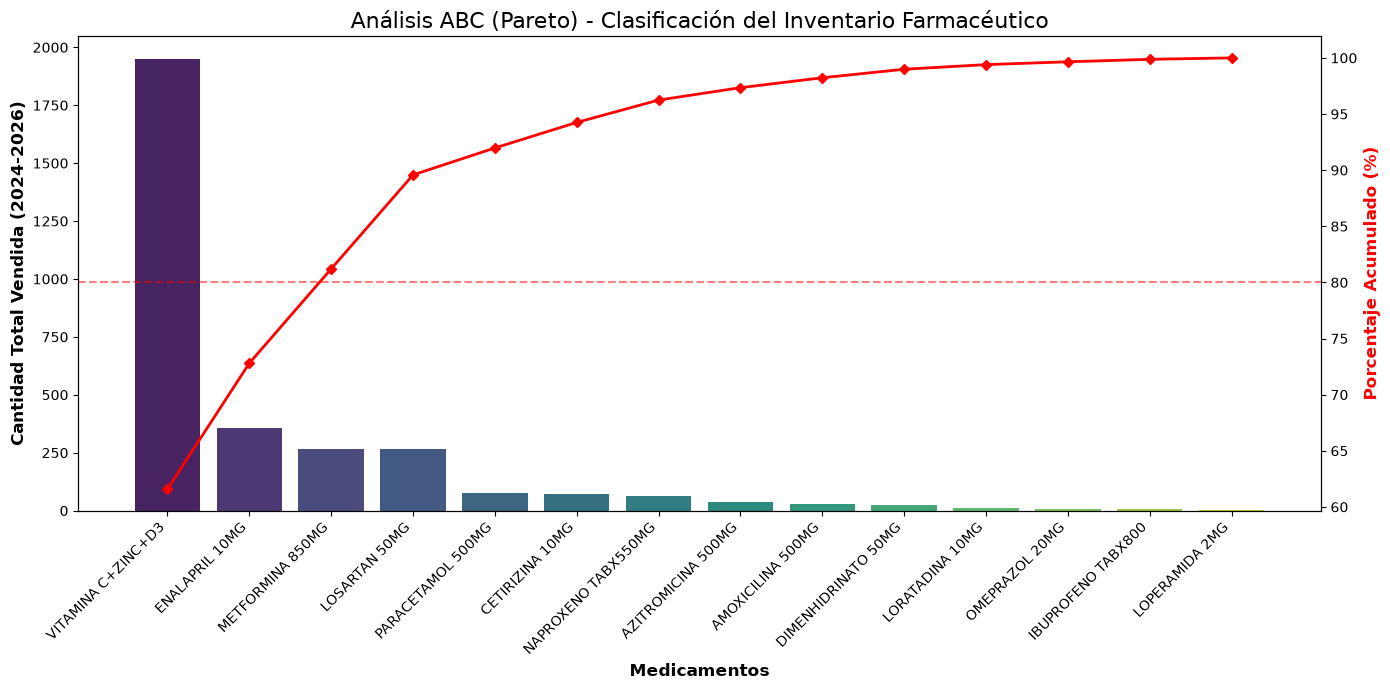


MEDICAMENTOS CLASE A (Foco del Dashboard)s
          producto  cantidad  porcentaje_acumulado
VITAMINA C+ZINC+D3    1950.0             61.591914
    ENALAPRIL 10MG     355.0             72.804801


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# ==========================================
# 1. LECTURA AUTOMÁTICA Y CONSOLIDACIÓN
# ==========================================
# Ruta donde guardaste tus CSV limpios en el paso anterior
ruta_carpeta = "../datasets/final/" 
archivos = glob.glob(os.path.join(ruta_carpeta, "*_final.csv"))

if not archivos:
    print(" No se encontraron archivos. Verifica que la ruta '../datasets/final/' sea correcta.")
else:
    print(f"Se encontraron {len(archivos)} archivos. Procesando...")

lista_dfs = []

for archivo in archivos:
    df_temp = pd.read_csv(archivo)
    
    # Extraer el nombre del producto desde el nombre del archivo
    # Ej: "AZITROMICINA 500MG(2024-2026)_final.csv" -> "AZITROMICINA 500MG"
    nombre_base = os.path.basename(archivo)
    nombre_producto = nombre_base.split('(')[0].replace('_final.csv', '').strip()
    
    # Asignar el nombre del producto a una nueva columna
    df_temp['producto'] = nombre_producto
    lista_dfs.append(df_temp)

# Unir todo en un solo DataFrame maestro
df_maestro = pd.concat(lista_dfs, ignore_index=True)
print(f" Datos consolidados con éxito. Total de registros: {len(df_maestro)}")

# ==========================================
# 2. ALGORITMO EDA: ANÁLISIS ABC (PARETO)
# ==========================================
# Agrupar por producto y sumar las cantidades
df_agrupado = df_maestro.groupby('producto')['cantidad'].sum().reset_index()
df_agrupado = df_agrupado.sort_values(by='cantidad', ascending=False)

# Calcular porcentajes para la Ley de Pareto
df_agrupado['porcentaje'] = (df_agrupado['cantidad'] / df_agrupado['cantidad'].sum()) * 100
df_agrupado['porcentaje_acumulado'] = df_agrupado['porcentaje'].cumsum()

# Función de Clasificación de Inventarios
def clasificar_abc(porcentaje):
    if porcentaje <= 80:
        return 'A (Alta Rotación)'
    elif porcentaje <= 95:
        return 'B (Rotación Media)'
    else:
        return 'C (Baja Rotación)'

df_agrupado['Categoria_ABC'] = df_agrupado['porcentaje_acumulado'].apply(clasificar_abc)

# ==========================================
# 3. VISUALIZACIÓN EJECUTIVA
# ==========================================
plt.figure(figsize=(14, 7))

# Limitar a los Top 30 para que el gráfico sea legible
top_n = min(30, len(df_agrupado))
df_top = df_agrupado.head(top_n)

# Barras de cantidades (Eje Y izquierdo)
ax1 = sns.barplot(data=df_top, x='producto', y='cantidad', palette='viridis')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax1.set_ylabel('Cantidad Total Vendida (2024-2026)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Medicamentos', fontsize=12, fontweight='bold')

# Línea de Pareto (Eje Y derecho)
ax2 = ax1.twinx()
ax2.plot(df_top['producto'], df_top['porcentaje_acumulado'], color='red', marker='D', ms=5, linewidth=2)
ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=12, fontweight='bold', color='red')
ax2.axhline(80, color='red', linestyle='--', alpha=0.5, label='Línea de Corte (80%)')

plt.title('Análisis ABC (Pareto) - Clasificación del Inventario Farmacéutico', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================
# 4. RESULTADOS: LOS MEDICAMENTOS CRÍTICOS
# ==========================================
print("\nMEDICAMENTOS CLASE A (Foco del Dashboard)s")
clase_a = df_agrupado[df_agrupado['Categoria_ABC'] == 'A (Alta Rotación)']
print(clase_a[['producto', 'cantidad', 'porcentaje_acumulado']].to_string(index=False))

## Resumen completo A/B/C
Se conserva la clasificación existente por porcentaje acumulado (80% y 95%). El universo corresponde a los productos disponibles en los CSV procesados; los porcentajes representan volumen en `cantidad`, no valor monetario ni todo el catálogo de la farmacia.


In [2]:
categorias = ['A (Alta Rotación)', 'B (Rotación Media)', 'C (Baja Rotación)']
resumen_abc = (df_agrupado.groupby('Categoria_ABC')
               .agg(productos=('producto', 'nunique'), cantidad=('cantidad', 'sum'))
               .reindex(categorias, fill_value=0))
resumen_abc['porcentaje_productos'] = resumen_abc['productos'] / df_agrupado['producto'].nunique() * 100
resumen_abc['porcentaje_volumen'] = resumen_abc['cantidad'] / df_agrupado['cantidad'].sum() * 100
resumen_abc['porcentaje_volumen_acumulado'] = resumen_abc['porcentaje_volumen'].cumsum()
print('RESUMEN COMPLETO A/B/C')
display(resumen_abc)
print('DETALLE DE TODOS LOS PRODUCTOS')
display(df_agrupado[['producto', 'cantidad', 'porcentaje', 'porcentaje_acumulado', 'Categoria_ABC']])

RESUMEN COMPLETO A/B/C


,productos,cantidad,porcentaje_productos,porcentaje_volumen,porcentaje_volumen_acumulado
Categoria_ABC,,,,,
A (Alta Rotación),2,2305.0,14.285714,72.804801,72.804801
B (Rotación Media),4,679.0,28.571429,21.446620,94.251421
C (Baja Rotación),8,182.0,57.142857,5.748579,100.000000


DETALLE DE TODOS LOS PRODUCTOS


,producto,cantidad,porcentaje,porcentaje_acumulado,Categoria_ABC
13,VITAMINA C+ZINC+D3,1950.0,61.591914,61.591914,A (Alta Rotación)
4,ENALAPRIL 10MG,355.0,11.212887,72.804801,A (Alta Rotación)
9,METFORMINA 850MG,266.0,8.401769,81.206570,B (Rotación Media)
8,LOSARTAN 50MG,265.0,8.370183,89.576753,B (Rotación Media)
12,PARACETAMOL 500MG,76.0,2.400505,91.977258,B (Rotación Media)
2,CETIRIZINA 10MG,72.0,2.274163,94.251421,B (Rotación Media)
10,NAPROXENO TABX550MG,63.0,1.989893,96.241314,C (Baja Rotación)
1,AZITROMICINA 500MG,35.0,1.105496,97.346810,C (Baja Rotación)
0,AMOXICILINA 500MG,28.0,0.884397,98.231207,C (Baja Rotación)
3,DIMENHIDRINATO 50MG,24.0,0.758054,98.989261,C (Baja Rotación)
